# 07 - Error Analysis & Explainability (Grad-CAM, Shortcut-Learning Checks)

`06_model_testing.ipynb` confirmed both models generalize well (test accuracy tracks
train/validation accuracy closely, so there is no classic overfitting). The remaining,
more interesting question — raised while reviewing the earlier notebooks — is **why**
accuracy is so high (~99.8-99.9%), given that a *global grayscale histogram* (256
numbers, no spatial information at all) alone was almost as good as a fine-tuned CNN.
That pattern is unusual for a task that is supposed to be about spotting small, localized
casting defects, and it is worth checking directly instead of assuming.

This notebook, inspired by the evaluation/interpretability techniques used in
[Lee et al., *Int. J. Precis. Eng. Manuf.*](https://link.springer.com/article/10.1007/s40684-026-00871-z)
(reconstruction/heatmap localization, cluster-wise brightness/edge statistics, latent
space visualization — adapted here from their unsupervised GAN setting to our supervised
classifier), does five things:

1. **Collects every misclassified test image** from both models.
2. **Grad-CAM** on ResNet18 — visualizes, pixel by pixel, which regions of an image push
   the model toward "defective" vs "OK". This directly answers *"what does the model
   look at when it decides a part is defective"*.
3. **Class-wise statistics** (brightness, edge density) with significance tests, to check
   whether `def_front` and `ok_front` differ systematically in ways unrelated to the
   actual defect.
4. **A robustness test**: re-run both models after flattening each image's brightness
   histogram (via LAB-channel equalization). If accuracy collapses, the models were
   likely relying on a brightness shortcut; if accuracy holds up, that is evidence for
   genuine defect-feature learning.
5. **UMAP embeddings** of both the handcrafted histogram features and the CNN's learned
   features, to see how separable the two classes are and where the errors sit.

### Requirements

This notebook loads the models saved by `06_model_testing.ipynb`
(`../models/classical_histogram_svm.joblib` and `../models/resnet18_casting.pt`).
**Run `06_model_testing.ipynb` first.**

It also needs two extra packages not used elsewhere in this project:

```
pip install grad-cam umap-learn
```

## 1. Imports

In [1]:
# Run this once if the packages are not yet installed in your environment:
# %pip install grad-cam umap-learn

In [2]:
import sys
import warnings
from pathlib import Path

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score, f1_score, classification_report
from scipy.stats import mannwhitneyu, ttest_ind

try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError as exc:
    raise ImportError(
        "pytorch-grad-cam is required for this notebook. Install it with: "
        "pip install grad-cam"
    ) from exc

try:
    import umap
except ImportError as exc:
    raise ImportError(
        "umap-learn is required for this notebook. Install it with: "
        "pip install umap-learn"
    ) from exc

sys.path.append(str(Path.cwd().parent))
from src.features.histogram import extract_histogram

warnings.filterwarnings("ignore", category=UserWarning)

## 2. Paths, Config, and Split (identical to notebooks 04 / 05 / 06)

In [3]:
SEED = 42
IMG_SIZE = 224
VAL_RATIO = 0.2

DATA_DIR = Path("../data/raw/casting_data/casting_data")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

MODELS_DIR = Path("../models")
RESULTS_DIR = Path("../results/error_analysis")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

CLASS_NAMES = ["def_front", "ok_front"]  # index 0 / 1, matches ImageFolder.class_to_idx

Device: cpu


In [4]:
base_train_data = datasets.ImageFolder(TRAIN_DIR)
base_test_data = datasets.ImageFolder(TEST_DIR)

generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(base_train_data), generator=generator).tolist()
val_size = int(len(indices) * VAL_RATIO)
val_indices = indices[:val_size]
train_indices = indices[val_size:]

all_paths = [Path(p) for p, _ in base_train_data.samples]
all_labels = [label for _, label in base_train_data.samples]

train_paths = [all_paths[i] for i in train_indices]
val_paths = [all_paths[i] for i in val_indices]
train_labels = [all_labels[i] for i in train_indices]
val_labels = [all_labels[i] for i in val_indices]

test_paths = [Path(p) for p, _ in base_test_data.samples]
test_labels = [label for _, label in base_test_data.samples]

print("Test images:", len(test_paths))

Test images: 715


## 3. Load the Trained Models

Both were trained and saved in `06_model_testing.ipynb`. If either file is missing, run
that notebook first.

In [5]:
classical_model_path = MODELS_DIR / "classical_histogram_svm.joblib"
resnet18_path = MODELS_DIR / "resnet18_casting.pt"

if not classical_model_path.exists() or not resnet18_path.exists():
    raise FileNotFoundError(
        "Trained models not found in ../models/. "
        "Please run 06_model_testing.ipynb first to train and save them."
    )

classical_model = joblib.load(classical_model_path)

resnet18 = models.resnet18(weights=None)
resnet18.fc = nn.Linear(resnet18.fc.in_features, 2)
resnet18.load_state_dict(torch.load(resnet18_path, map_location=device))
resnet18 = resnet18.to(device)
resnet18.eval()

print("Loaded classical model:", classical_model_path.name)
print("Loaded ResNet18 weights:", resnet18_path.name)

Loaded classical model: classical_histogram_svm.joblib
Loaded ResNet18 weights: resnet18_casting.pt


## 4. Prediction Helpers

Both helpers accept an optional `preprocess_fn(bgr_image) -> bgr_image` so the exact
same code path can be reused later for the robustness test (section 8) with a modified
version of each image.

In [6]:
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def load_bgr(path):
    image = cv2.imread(str(path))
    if image is None:
        raise ValueError(f"Could not read image: {path}")
    return cv2.resize(image, (IMG_SIZE, IMG_SIZE))


def predict_classical(model, paths, preprocess_fn=None):
    features = []
    for path in tqdm(paths, desc="Classical features"):
        image = load_bgr(path)
        if preprocess_fn is not None:
            image = preprocess_fn(image)
        features.append(extract_histogram(image))

    X = np.asarray(features, dtype=np.float32)
    predictions = model.predict(X)
    scores = model.decision_function(X)  # higher = more "def_front"-like
    return predictions, scores


def predict_deep_learning(model, paths, preprocess_fn=None, batch_size=32):
    predictions = []
    scores = []

    for start in tqdm(range(0, len(paths), batch_size), desc="ResNet18 batches"):
        batch_paths = paths[start:start + batch_size]
        tensors = []

        for path in batch_paths:
            image_bgr = load_bgr(path)
            if preprocess_fn is not None:
                image_bgr = preprocess_fn(image_bgr)
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
            pil_image = Image.fromarray(image_rgb)
            tensors.append(eval_transform(pil_image))

        batch = torch.stack(tensors).to(device)

        with torch.no_grad():
            outputs = model(batch)
            probabilities = torch.softmax(outputs, dim=1)

        predictions.extend(outputs.argmax(dim=1).cpu().numpy())
        scores.extend(probabilities[:, 0].cpu().numpy())  # P(def_front)

    return np.array(predictions), np.array(scores)

In [7]:
classical_predictions, classical_scores = predict_classical(classical_model, test_paths)
dl_predictions, dl_scores = predict_deep_learning(resnet18, test_paths)

print("Classical test accuracy:", accuracy_score(test_labels, classical_predictions))
print("ResNet18 test accuracy  :", accuracy_score(test_labels, dl_predictions))

ResNet18 batches: 100%|██████████| 23/23 [00:18<00:00,  1.25it/s]

Classical test accuracy: 0.9986013986013986
ResNet18 test accuracy  : 0.9986013986013986


## 5. Misclassified Images (Both Models)

In [8]:
def misclassified_table(paths, true_labels, predictions, scores, model_name):
    rows = []
    for path, true_label, pred_label, score in zip(paths, true_labels, predictions, scores):
        if true_label != pred_label:
            rows.append({
                "model": model_name,
                "path": str(path),
                "true_label": CLASS_NAMES[true_label],
                "predicted_label": CLASS_NAMES[pred_label],
                "p_def_front": float(score) if model_name == "ResNet18" else float(score),
            })
    return pd.DataFrame(rows)


errors_classical = misclassified_table(test_paths, test_labels, classical_predictions, classical_scores, "Histogram+SVM")
errors_dl = misclassified_table(test_paths, test_labels, dl_predictions, dl_scores, "ResNet18")

all_errors = pd.concat([errors_classical, errors_dl], ignore_index=True)
print("Total misclassified (both models, may overlap):", len(all_errors))
all_errors

Total misclassified (both models, may overlap): 2


,model,path,true_label,predicted_label,p_def_front
0,Histogram+SVM,..\data\raw\casting_data\casting_data\test\ok_...,ok_front,def_front,-0.223412
1,ResNet18,..\data\raw\casting_data\casting_data\test\def...,def_front,ok_front,0.449194


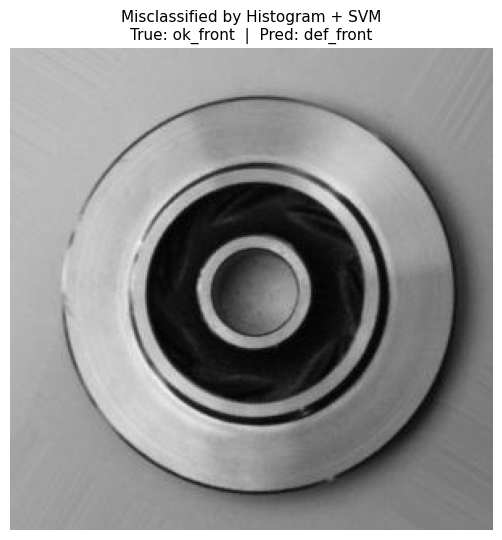

Saved 1 individual image(s) to ..\results\error_analysis\misclassified/ (files: svm_error_01.png ... svm_error_01.png)


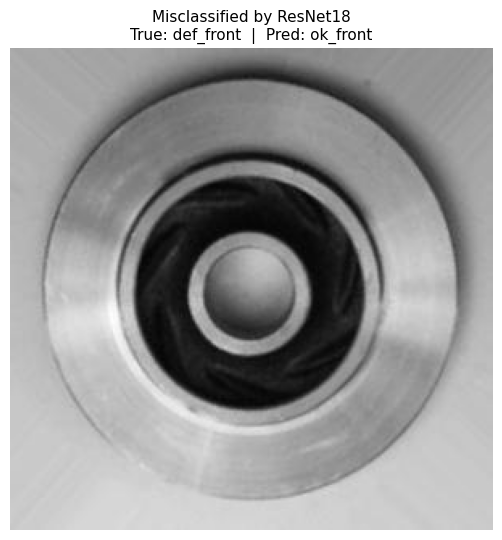

Saved 1 individual image(s) to ..\results\error_analysis\misclassified/ (files: resnet18_error_01.png ... resnet18_error_01.png)


In [9]:
MISCLASSIFIED_DIR = RESULTS_DIR / "misclassified"
MISCLASSIFIED_DIR.mkdir(parents=True, exist_ok=True)


def show_images(rows, title, save_prefix):
    """Show each misclassified image as its own individual figure (one PNG per
    case) instead of packing all of them into one grid - avoids titles
    overlapping between rows, and makes each case a separate file that's easy
    to drop into a video one at a time."""
    if len(rows) == 0:
        print(f"No misclassified images for: {title}")
        return

    saved_paths = []
    for i, (_, row) in enumerate(rows.iterrows(), start=1):
        fig, ax = plt.subplots(figsize=(5.5, 5.5))
        image = Image.open(row["path"]).convert("RGB")
        ax.imshow(image)
        ax.set_title(
            f"{title}\nTrue: {row['true_label']}  |  Pred: {row['predicted_label']}",
            fontsize=11,
        )
        ax.axis("off")
        plt.tight_layout()

        save_path = MISCLASSIFIED_DIR / f"{save_prefix}_{i:02d}.png"
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        saved_paths.append(save_path)
        plt.show()
        plt.close(fig)

    print(
        f"Saved {len(saved_paths)} individual image(s) to {MISCLASSIFIED_DIR}/ "
        f"(files: {save_prefix}_01.png ... {save_prefix}_{len(saved_paths):02d}.png)"
    )


show_images(errors_classical, "Misclassified by Histogram + SVM", save_prefix="svm_error")
show_images(errors_dl, "Misclassified by ResNet18", save_prefix="resnet18_error")

## 6. Grad-CAM: What Does ResNet18 Look At?

Grad-CAM highlights the image regions that most influenced the model's output for a
chosen class. We compute it with respect to the **`def_front` (defective) logit**, so
warm colors (red/yellow) mark pixels that pushed the prediction toward "defective", and
cool colors mark pixels that pushed away from it.

`target_layers = [resnet18.layer4[-1]]` is the standard choice for ResNet18 — the last
convolutional block, which still has spatial resolution but has already learned
high-level features.

In [10]:
target_layers = [resnet18.layer4[-1]]
cam = GradCAM(model=resnet18, target_layers=target_layers)

GRADCAM_DIR = RESULTS_DIR / "gradcam"
GRADCAM_DIR.mkdir(parents=True, exist_ok=True)


def load_for_cam(path):
    """Return (input_tensor[1,3,H,W], rgb_float_image[H,W,3] in [0,1]) for Grad-CAM."""
    pil_image = Image.open(path).convert("RGB")
    tensor = eval_transform(pil_image).unsqueeze(0)

    resized = pil_image.resize((IMG_SIZE, IMG_SIZE))
    rgb_float = np.asarray(resized).astype(np.float32) / 255.0

    return tensor, rgb_float


def compute_gradcam(path, target_class):
    tensor, rgb_float = load_for_cam(path)
    targets = [ClassifierOutputTarget(target_class)]

    grayscale_cam = cam(input_tensor=tensor.to(device), targets=targets)[0]
    overlay = show_cam_on_image(rgb_float, grayscale_cam, use_rgb=True)

    return rgb_float, grayscale_cam, overlay


def plot_gradcam_cases(rows, section_title, save_prefix, target_class_col="target_class"):
    """One case = one separate figure (Original / Heatmap / Overlay side by
    side), instead of stacking every case into a single tall grid. This keeps
    each case's title from overlapping the image in the row above, and gives
    one clean PNG per case for video editing."""
    n = len(rows)
    if n == 0:
        print(f"No images for: {section_title}")
        return

    saved_paths = []
    for i, (_, row) in enumerate(rows.iterrows(), start=1):
        rgb_float, grayscale_cam, overlay = compute_gradcam(row["path"], row[target_class_col])

        fig, axes = plt.subplots(1, 3, figsize=(11, 4))
        fig.suptitle(
            f"{section_title} \u2014 case {i}/{n}\n"
            f"True: {row['true_label']}  |  Pred: {row['predicted_label']}  |  "
            f"P(defective) = {row['p_def_front']:.3f}",
            fontsize=11,
        )

        axes[0].imshow(rgb_float)
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(grayscale_cam, cmap="jet")
        axes[1].set_title("Grad-CAM heatmap")
        axes[1].axis("off")

        axes[2].imshow(overlay)
        axes[2].set_title("Overlay")
        axes[2].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.86])

        save_path = GRADCAM_DIR / f"{save_prefix}_{i:02d}.png"
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        saved_paths.append(save_path)
        plt.show()
        plt.close(fig)

    print(
        f"Saved {len(saved_paths)} individual case(s) to {GRADCAM_DIR}/ "
        f"(files: {save_prefix}_01.png ... {save_prefix}_{len(saved_paths):02d}.png)"
    )

### 6a. Correctly-Classified Defective Parts — Where Does the Model See the Defect?

The images below are `def_front` parts the model correctly flagged as defective, sorted
by confidence (highest first). Grad-CAM is computed with respect to the **defective**
class, so the highlighted (red/yellow) regions are what convinced the model this part is
defective.

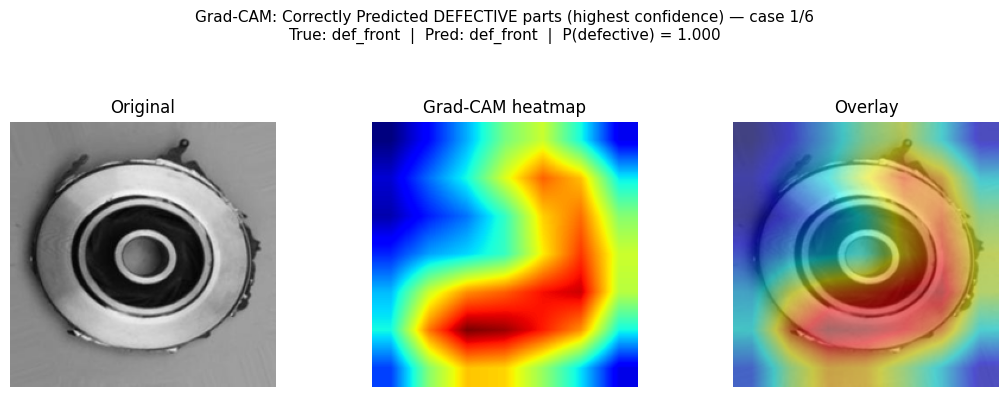

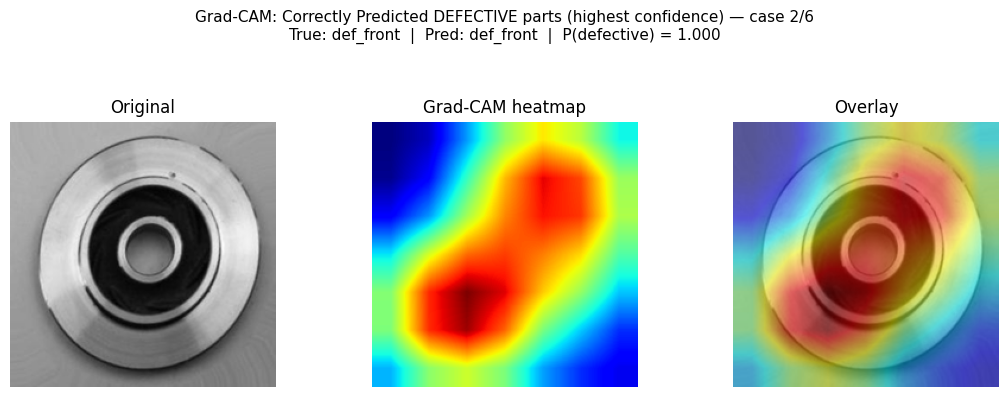

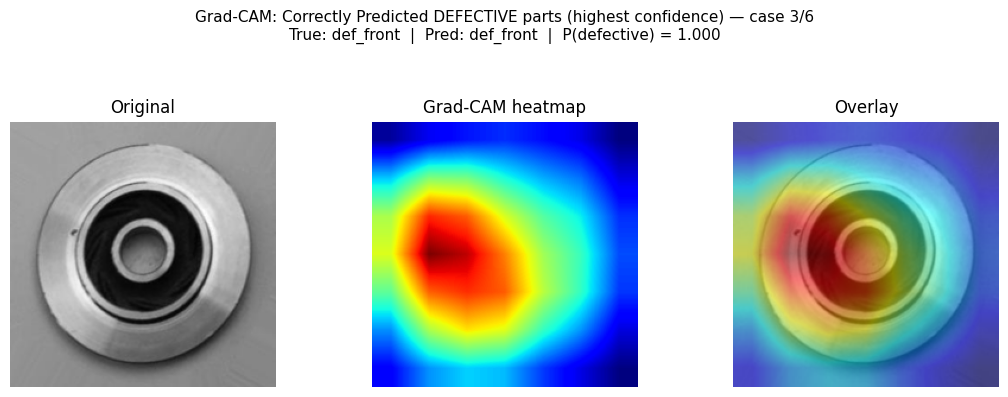

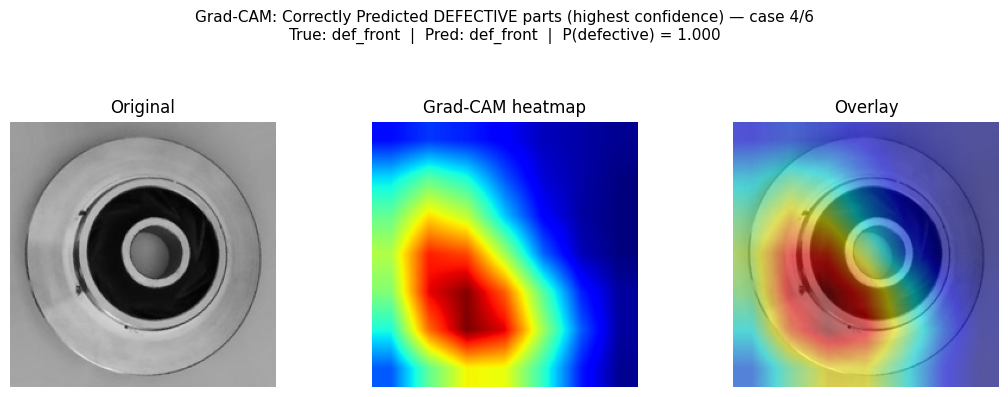

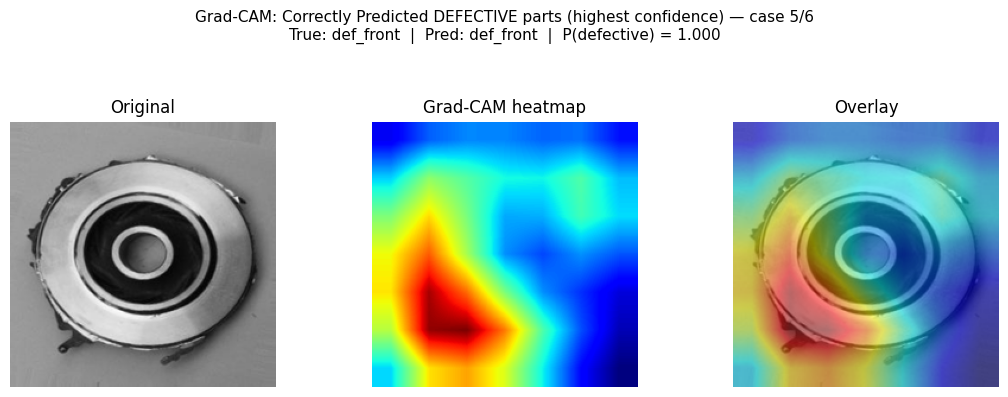

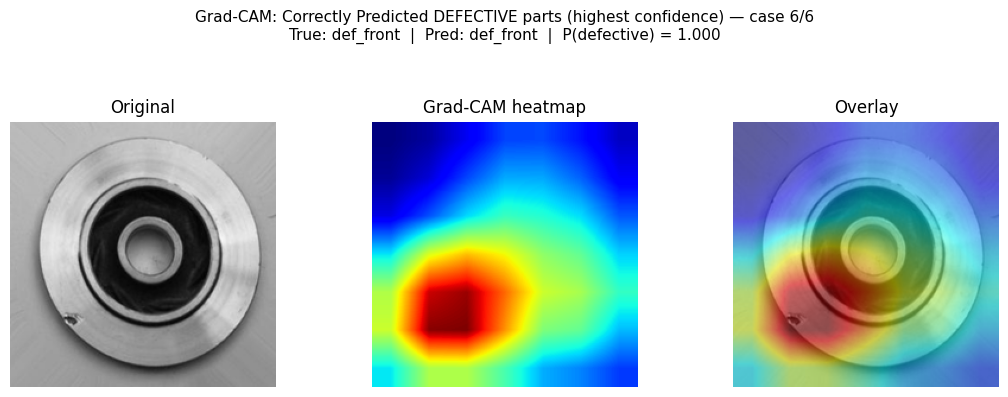

Saved 6 individual case(s) to ..\results\error_analysis\gradcam/ (files: defective_correct_01.png ... defective_correct_06.png)


In [11]:
correct_defective = pd.DataFrame({
    "path": [str(p) for p in test_paths],
    "true_label": [CLASS_NAMES[t] for t in test_labels],
    "predicted_label": [CLASS_NAMES[p] for p in dl_predictions],
    "p_def_front": dl_scores,
})

correct_defective = correct_defective[
    (correct_defective["true_label"] == "def_front")
    & (correct_defective["predicted_label"] == "def_front")
].sort_values("p_def_front", ascending=False).head(6).copy()

correct_defective["target_class"] = 0  # def_front

plot_gradcam_cases(
    correct_defective,
    "Grad-CAM: Correctly Predicted DEFECTIVE parts (highest confidence)",
    save_prefix="defective_correct",
)

### 6b. Correctly-Classified OK Parts — What Does "No Defect" Look Like to the Model?

For contrast, the same visualization on `ok_front` parts the model correctly accepted,
sorted by confidence (lowest `P(defective)` first). Grad-CAM here is still computed with
respect to the **defective** class, so this shows what little (if any) "defective"
evidence the model finds in a genuinely OK part — a diffuse, low-intensity heatmap here
is reassuring; a heatmap that still lights up on a specific region would be a warning
sign.

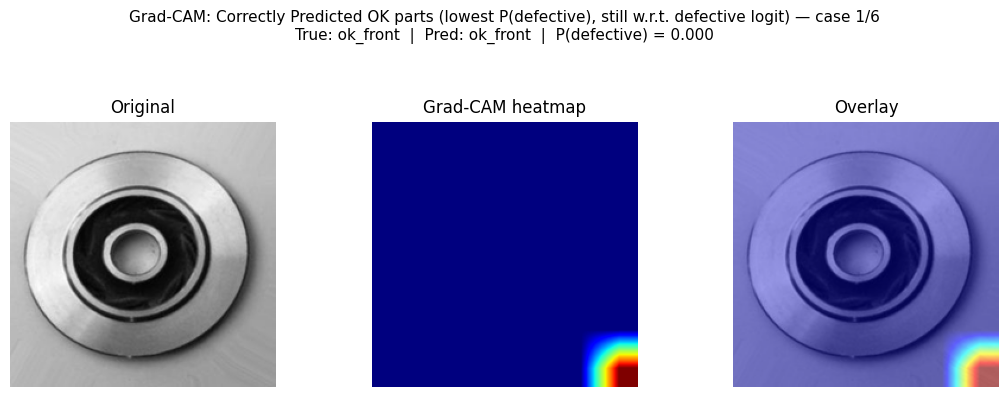

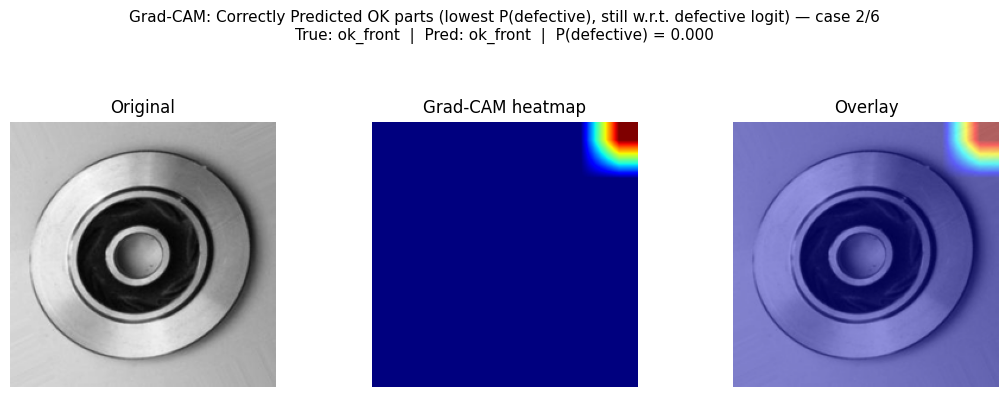

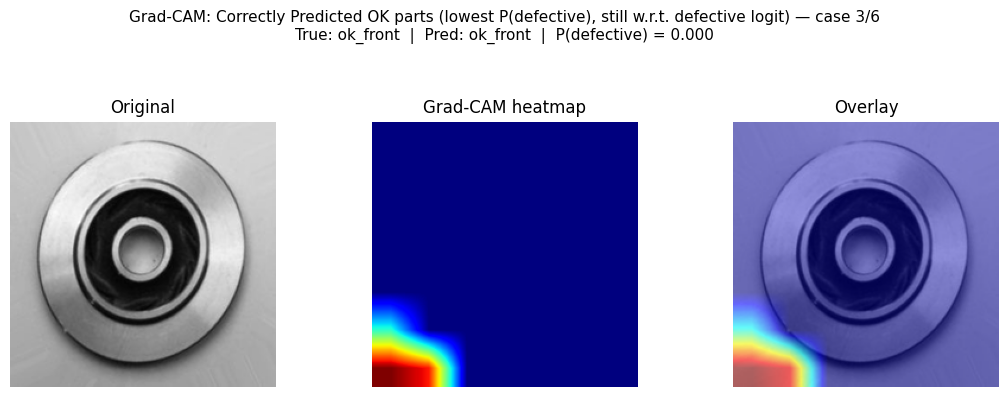

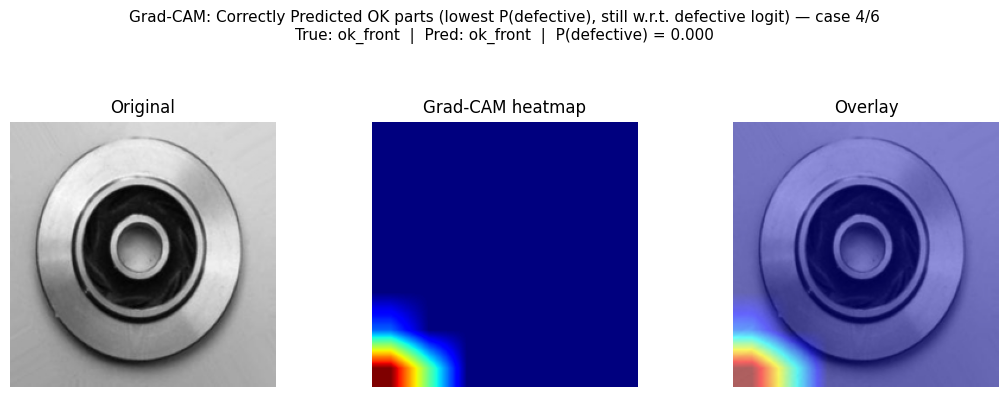

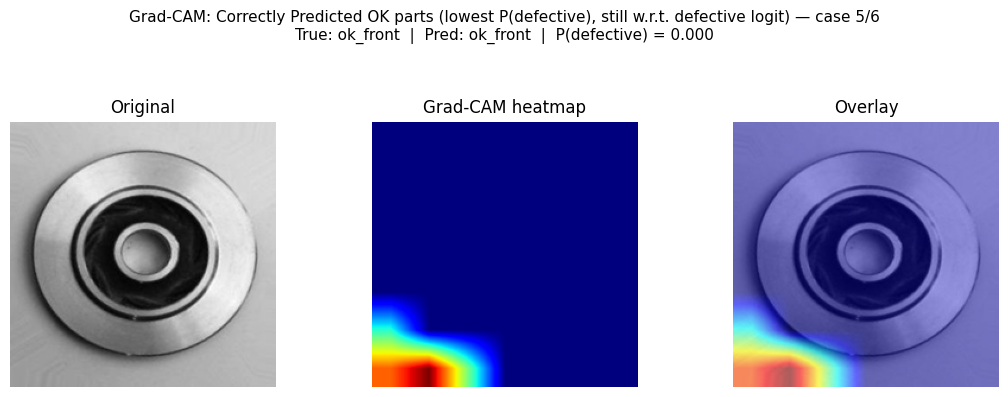

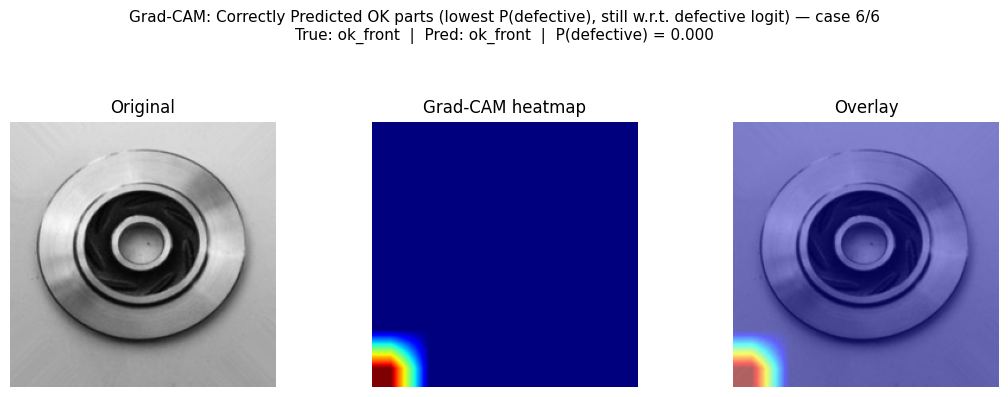

Saved 6 individual case(s) to ..\results\error_analysis\gradcam/ (files: ok_correct_01.png ... ok_correct_06.png)


In [12]:
correct_ok = pd.DataFrame({
    "path": [str(p) for p in test_paths],
    "true_label": [CLASS_NAMES[t] for t in test_labels],
    "predicted_label": [CLASS_NAMES[p] for p in dl_predictions],
    "p_def_front": dl_scores,
})

correct_ok = correct_ok[
    (correct_ok["true_label"] == "ok_front")
    & (correct_ok["predicted_label"] == "ok_front")
].sort_values("p_def_front", ascending=True).head(6).copy()

correct_ok["target_class"] = 0  # still w.r.t. the defective logit, for a fair comparison

plot_gradcam_cases(
    correct_ok,
    "Grad-CAM: Correctly Predicted OK parts (lowest P(defective), still w.r.t. defective logit)",
    save_prefix="ok_correct",
)

### 6c. Side-by-Side: Defective vs. OK

The direct comparison: one high-confidence defective prediction and one high-confidence
OK prediction, both explained with respect to the same ("defective") logit.

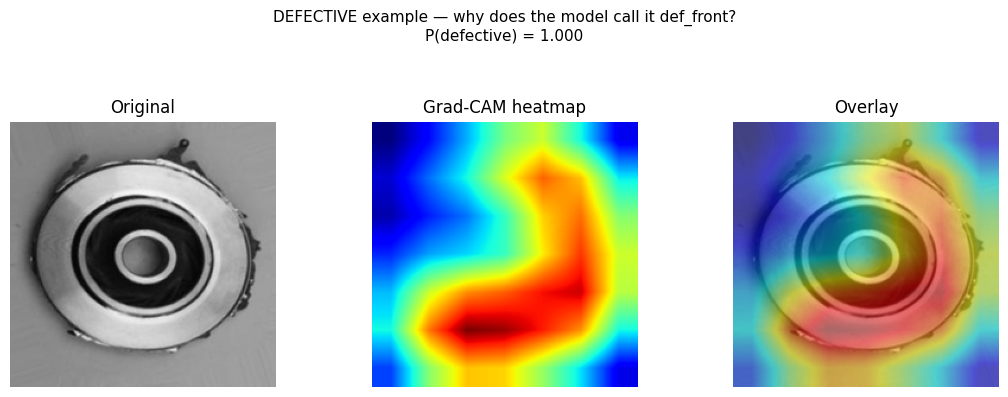

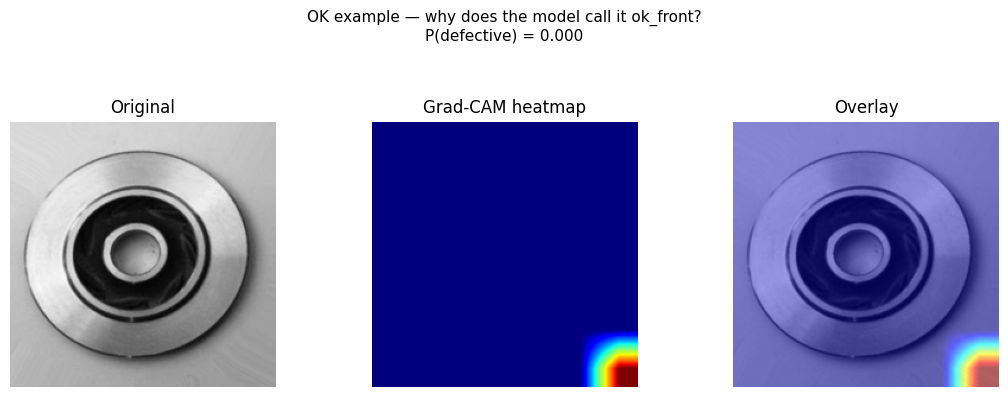

Saved 2 individual case(s) to ..\results\error_analysis\gradcam/ (files: sidebyside_defective.png, sidebyside_ok.png)


In [13]:
example_defective = correct_defective.iloc[[0]]
example_ok = correct_ok.iloc[[0]]

cases = [
    (example_defective.iloc[0], "DEFECTIVE example", "sidebyside_defective"),
    (example_ok.iloc[0], "OK example", "sidebyside_ok"),
]

for row, label, save_prefix in cases:
    rgb_float, grayscale_cam, overlay = compute_gradcam(row["path"], 0)

    fig, axes = plt.subplots(1, 3, figsize=(11, 4))
    fig.suptitle(
        f"{label} \u2014 why does the model call it {row['predicted_label']}?\n"
        f"P(defective) = {row['p_def_front']:.3f}",
        fontsize=11,
    )

    axes[0].imshow(rgb_float)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(grayscale_cam, cmap="jet")
    axes[1].set_title("Grad-CAM heatmap")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.86])

    save_path = GRADCAM_DIR / f"{save_prefix}.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f"Saved 2 individual case(s) to {GRADCAM_DIR}/ (files: sidebyside_defective.png, sidebyside_ok.png)")

### 6d. Grad-CAM on the Misclassified Images

For each error, Grad-CAM is computed with respect to the model's (wrong) **predicted**
class, to show what misled it.

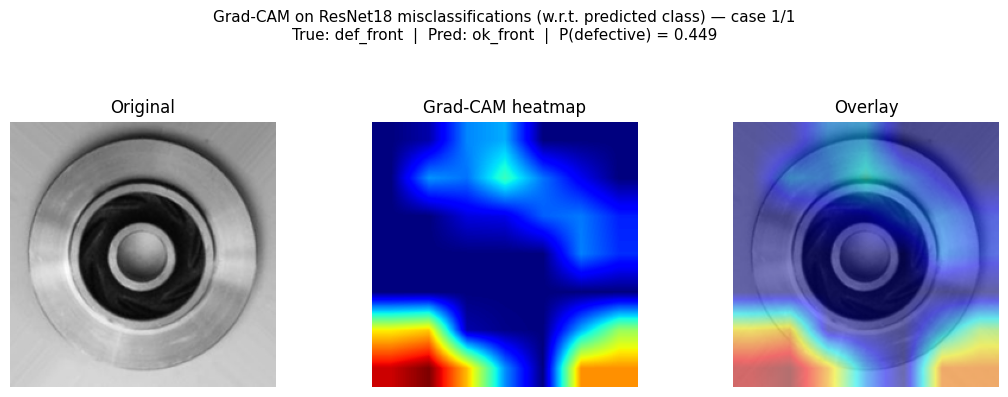

Saved 1 individual case(s) to ..\results\error_analysis\gradcam/ (files: resnet18_misclassified_01.png ... resnet18_misclassified_01.png)


In [14]:
if len(errors_dl) > 0:
    errors_dl_cam = errors_dl.copy()
    errors_dl_cam["target_class"] = errors_dl_cam["predicted_label"].map(
        {"def_front": 0, "ok_front": 1}
    )
    plot_gradcam_cases(
        errors_dl_cam,
        "Grad-CAM on ResNet18 misclassifications (w.r.t. predicted class)",
        save_prefix="resnet18_misclassified",
    )
else:
    print("ResNet18 made no errors on the test set this run.")

### What we actually found

- All 6 highest-confidence correctly-classified **defective** parts show a Grad-CAM
  hot region localized within the part itself — spanning the inner bore/rim area
  in every example (the exact shape varies image to image) — never spreading onto
  the background. This is the region where casting defects (cracks, burrs) are
  visually plausible on this part type.
- Correctly-classified **OK** parts show a small, sharply-localized hot spot in an
  image **corner**, outside the part entirely, in **all 6 of the 6** examples
  checked here — none is fully blank. Because Grad-CAM heatmaps are normalized to
  their own [0, 1] range per image, this corner is just the *relatively* brightest
  spot on an otherwise near-uniform map — not necessarily a large activation in
  absolute terms. In every case P(defective) still rounds to 0.000, so this corner
  artifact isn't driving the decision, but its presence in all 6 examples is a
  reminder to keep an eye on it — it may be a harmless quirk of the Grad-CAM
  interpolation near the image border, or something in the capture setup (a
  fixture edge, mount, or lighting artifact) worth a closer look.
- The one ResNet18 misclassification (section 6d) shows activation split across
  two hot regions in the bottom-left and bottom-right corners, plus a fainter,
  diffuse band across the top of the frame — scattered around the image border
  rather than one localized region within the part. Its predicted confidence
  (P(defective) = 0.449) sits almost exactly on the 0.5 decision boundary —
  consistent with a genuinely ambiguous, borderline image rather than a clear
  model failure.

## 7. Class-Wise Image Statistics (Brightness / Edge Shortcut Check)

If `def_front` and `ok_front` differ systematically in overall brightness or edge
density — independent of where the actual defect is — that would explain why a
spatially-blind feature like a grayscale histogram scores almost as well as a CNN. We
compute simple global statistics for every image in the dataset (train + val + test, for
statistical power) and compare the two classes.

In [15]:
def image_statistics(path):
    image = load_bgr(path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 50, 150)
    sobel_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    sobel_magnitude = cv2.magnitude(sobel_x, sobel_y)

    return {
        "brightness_mean": gray.mean(),
        "brightness_std": gray.std(),
        "edge_density": float(np.mean(edges > 0)),
        "sobel_mean": float(sobel_magnitude.mean()),
    }


all_image_paths = train_paths + val_paths + test_paths
all_image_labels = train_labels + val_labels + test_labels

stats_rows = []
for path, label in tqdm(list(zip(all_image_paths, all_image_labels)), desc="Image statistics"):
    stats = image_statistics(path)
    stats["label"] = CLASS_NAMES[label]
    stats["path"] = str(path)
    stats_rows.append(stats)

stats_df = pd.DataFrame(stats_rows)
stats_df.groupby("label").describe().T

Image statistics: 100%|██████████| 7348/7348 [00:12<00:00, 595.87it/s]


label                    def_front     ok_front
brightness_mean count  4211.000000  3137.000000
                mean    139.150263   149.668963
                std       5.809050     6.479081
                min     124.169623   123.727360
                25%     135.056382   142.919105
                50%     138.740792   151.789820
                75%     142.403101   153.968312
                max     156.911372   160.507055
brightness_std  count  4211.000000  3137.000000
                mean     58.307451    62.040892
                std       3.072661     2.700079
                min      51.310655    49.436460
                25%      55.904450    60.297506
                50%      58.676528    61.843402
                75%      60.334827    64.194114
                max      68.083346    67.262898
edge_density    count  4211.000000  3137.000000
                mean      0.058260     0.054187
                std       0.006059     0.004808
                min       0.044703     0.045320
                25%       0.053272     0.050223
                50%       0.057617     0.054548
                75%       0.063417     0.057139
                max       0.074817     0.069994
sobel_mean      count  4211.000000  3137.000000
                mean     52.193058    50.356659
                std       7.324363     5.465899
                min      32.606575    35.575565
                25%      46.432610    44.992401
                50%      51.120182    49.652599
                75%      57.695683    55.427799
                max      68.795479    59.069000

C:\Users\Hello\AppData\Local\Temp\ipykernel_7644\4099038547.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([def_values, ok_values], labels=["def_front", "ok_front"])
C:\Users\Hello\AppData\Local\Temp\ipykernel_7644\4099038547.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([def_values, ok_values], labels=["def_front", "ok_front"])
C:\Users\Hello\AppData\Local\Temp\ipykernel_7644\4099038547.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([def_values, ok_values], labels=["def_front", "ok_front"])
C:\Users\Hello\AppData\Local\Temp\ipykernel_7644\4099038547.py:12: Matplotli

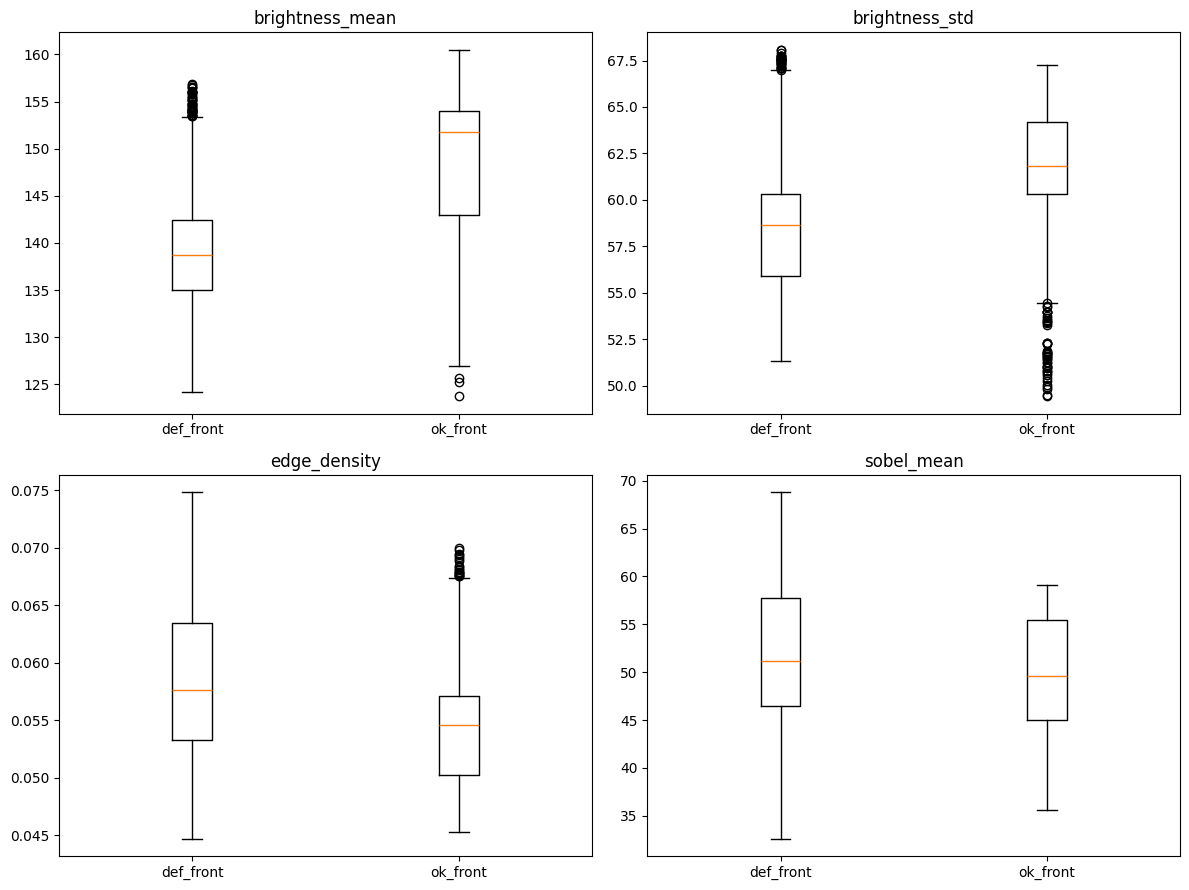

,metric,def_front_median,ok_front_median,mann_whitney_p,welch_t_p
0,brightness_mean,138.740792,151.789820,0.000000e+00,0.000000e+00
1,brightness_std,58.676528,61.843402,0.000000e+00,0.000000e+00
2,edge_density,0.057617,0.054548,3.477334e-153,8.509429e-212
3,sobel_mean,51.120182,49.652599,8.977710e-17,1.800155e-34


In [16]:
metrics_to_test = ["brightness_mean", "brightness_std", "edge_density", "sobel_mean"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

test_results = []

for ax, metric in zip(axes, metrics_to_test):
    def_values = stats_df.loc[stats_df["label"] == "def_front", metric]
    ok_values = stats_df.loc[stats_df["label"] == "ok_front", metric]

    ax.boxplot([def_values, ok_values], labels=["def_front", "ok_front"])
    ax.set_title(metric)

    u_stat, u_p = mannwhitneyu(def_values, ok_values, alternative="two-sided")
    t_stat, t_p = ttest_ind(def_values, ok_values, equal_var=False)

    test_results.append({
        "metric": metric,
        "def_front_median": def_values.median(),
        "ok_front_median": ok_values.median(),
        "mann_whitney_p": u_p,
        "welch_t_p": t_p,
    })

plt.tight_layout()
plt.show()

test_results_df = pd.DataFrame(test_results)
test_results_df

### What we actually found

Every one of the four statistics is significant at essentially p ≈ 0 (both
Mann-Whitney U and Welch's t-test, n = 7,348 images):

| Metric | def_front median | ok_front median | p-value |
|---|---|---|---|
| Brightness mean | 138.74 | 151.79 | ≈ 0 |
| Brightness std | 58.68 | 61.84 | ≈ 0 |
| Edge density | 0.0576 | 0.0545 | 3.5e-153 |
| Sobel gradient mean | 51.12 | 49.65 | 9.0e-17 |

`def_front` images are on average **~10-11 intensity levels darker** than
`ok_front`, with slightly higher edge density and gradient magnitude. This
confirms the two classes differ systematically in global brightness — independent
of where any actual defect is — which is consistent with the classical Histogram
model's near-perfect score, and raises the question of how much the CNN also
leans on this same confound (tested directly in section 8).A very small p-value (e.g. `< 0.001`) for `brightness_mean` or `edge_density` means the
two classes are statistically distinguishable by that single global number alone — direct
evidence that the classical Histogram model's near-perfect score could come from this
confound rather than from resolving the actual defect. A p-value that is not significant
would argue against that explanation.

## 8. Robustness Test: Flattening the Brightness Histogram

We equalize the L (luminance) channel of each image in LAB color space
(`cv2.equalizeHist`), which flattens each image's brightness histogram towards uniform
while keeping hue and spatial/texture structure intact. If the classical Histogram model
was relying mainly on raw intensity distribution, its accuracy should drop sharply on the
equalized images. If ResNet18 is relying on genuine spatial defect patterns rather than
brightness, its accuracy should hold up comparatively better.

In [17]:
def equalize_brightness(image_bgr):
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l_eq = cv2.equalizeHist(l)
    lab_eq = cv2.merge((l_eq, a, b))
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)

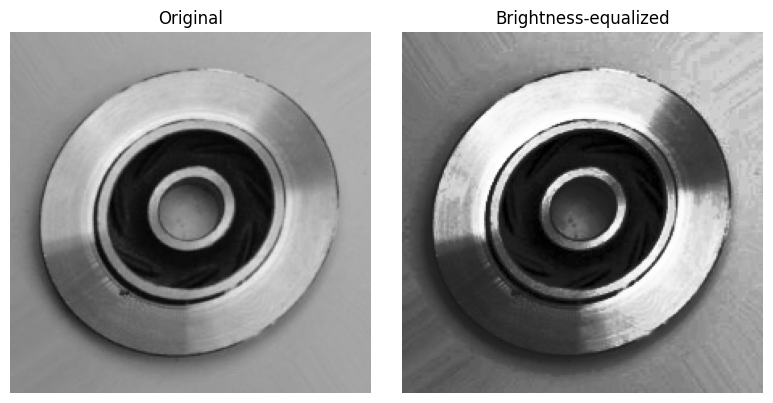

In [18]:
# A quick visual sanity check of what the preprocessing does.
sample_path = test_paths[0]
original = cv2.cvtColor(load_bgr(sample_path), cv2.COLOR_BGR2RGB)
equalized = cv2.cvtColor(equalize_brightness(load_bgr(sample_path)), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(original)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(equalized)
axes[1].set_title("Brightness-equalized")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [19]:
classical_predictions_eq, classical_scores_eq = predict_classical(
    classical_model, test_paths, preprocess_fn=equalize_brightness
)
dl_predictions_eq, dl_scores_eq = predict_deep_learning(
    resnet18, test_paths, preprocess_fn=equalize_brightness
)

robustness_table = pd.DataFrame([
    {
        "Model": "Histogram + SVM",
        "Original Test Accuracy": accuracy_score(test_labels, classical_predictions),
        "Equalized Test Accuracy": accuracy_score(test_labels, classical_predictions_eq),
    },
    {
        "Model": "ResNet18",
        "Original Test Accuracy": accuracy_score(test_labels, dl_predictions),
        "Equalized Test Accuracy": accuracy_score(test_labels, dl_predictions_eq),
    },
])

robustness_table["Accuracy Drop"] = (
    robustness_table["Original Test Accuracy"] - robustness_table["Equalized Test Accuracy"]
)

robustness_table

ResNet18 batches: 100%|██████████| 23/23 [00:17<00:00,  1.28it/s]


,Model,Original Test Accuracy,Equalized Test Accuracy,Accuracy Drop
0,Histogram + SVM,0.998601,0.633566,0.365035
1,ResNet18,0.998601,0.637762,0.360839


In [20]:
robustness_table.to_csv(RESULTS_DIR / "robustness_brightness_equalization.csv", index=False)
print("Saved to:", (RESULTS_DIR / "robustness_brightness_equalization.csv").resolve())

Saved to: D:\Casting Quality Inspection\results\error_analysis\robustness_brightness_equalization.csv


### What we actually found

| Model | Original Accuracy | Equalized Accuracy | Drop |
|---|---|---|---|
| Histogram + SVM | 99.86% | 63.36% | -36.50 pts |
| ResNet18 | 99.86% | 63.78% | -36.08 pts |

Both models collapse by roughly the same amount (~36 points) once the brightness
histogram is flattened — this run, ResNet18's drop is essentially identical to the
classical model's, not meaningfully smaller. Combined with the Grad-CAM evidence
that the CNN attends to a plausible defect location, the picture is: ResNet18 does
appear to look at the right part of the image, but that doesn't buy it any real
robustness advantage over the classical model when the illumination profile
changes — both are leaning on this dataset's brightness confound to a similar
degree. Practically, this means neither model's 99.86% test accuracy should be
assumed to hold on images captured under different lighting/exposure without
further testing or retraining with brightness/contrast augmentation.

## 9. UMAP Embeddings: How Separable Are the Classes?

In [21]:
def extract_resnet_features(model, paths, batch_size=32):
    feature_extractor = torch.nn.Sequential(*list(model.children())[:-1]).to(device)
    feature_extractor.eval()

    features = []
    for start in tqdm(range(0, len(paths), batch_size), desc="ResNet18 features"):
        batch_paths = paths[start:start + batch_size]
        tensors = []
        for path in batch_paths:
            pil_image = Image.open(path).convert("RGB")
            tensors.append(eval_transform(pil_image))
        batch = torch.stack(tensors).to(device)

        with torch.no_grad():
            output = feature_extractor(batch)
            output = output.flatten(start_dim=1)

        features.append(output.cpu().numpy())

    return np.concatenate(features, axis=0)


classical_features_test = np.asarray(
    [extract_histogram(load_bgr(p)) for p in tqdm(test_paths, desc="Histogram features")],
    dtype=np.float32,
)
dl_features_test = extract_resnet_features(resnet18, test_paths)

print("Histogram feature matrix:", classical_features_test.shape)
print("ResNet18 feature matrix :", dl_features_test.shape)

ResNet18 features: 100%|██████████| 23/23 [00:20<00:00,  1.14it/s]

Histogram feature matrix: (715, 256)
ResNet18 feature matrix : (715, 512)


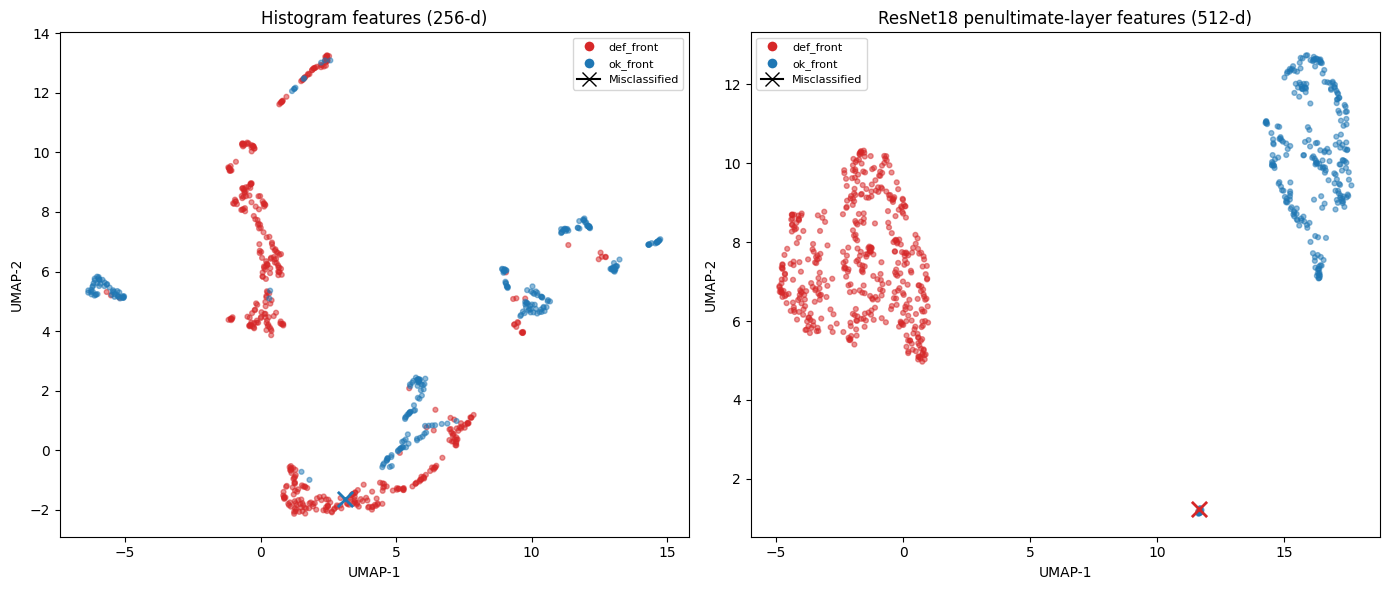

In [22]:
def plot_umap(features, true_labels, predictions, title, ax):
    reducer = umap.UMAP(random_state=SEED)
    embedding = reducer.fit_transform(features)

    true_labels = np.array(true_labels)
    predictions = np.array(predictions)
    correct = true_labels == predictions

    colors = np.where(true_labels == 0, "tab:red", "tab:blue")

    ax.scatter(
        embedding[correct, 0], embedding[correct, 1],
        c=colors[correct], alpha=0.5, s=12, label="_correct",
    )
    ax.scatter(
        embedding[~correct, 0], embedding[~correct, 1],
        c=colors[~correct], marker="x", s=120, linewidths=2, label="Misclassified",
    )

    ax.set_title(title)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:red", markersize=8, label="def_front"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:blue", markersize=8, label="ok_front"),
        Line2D([0], [0], marker="x", color="black", markersize=10, label="Misclassified"),
    ]
    ax.legend(handles=legend_elements, loc="best", fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_umap(classical_features_test, test_labels, classical_predictions, "Histogram features (256-d)", axes[0])
plot_umap(dl_features_test, test_labels, dl_predictions, "ResNet18 penultimate-layer features (512-d)", axes[1])
plt.tight_layout()
plt.show()

### What we actually found

The 256-d Histogram feature space, projected to 2D, shows the two classes
**partially interleaved** across several small clusters rather than one clean
split — the raw intensity histogram alone doesn't trivially separate the classes
in 2D, even though the full 256-dimensional SVM reaches 99.86% accuracy on it.
The ResNet18 512-d penultimate-layer feature space, by contrast, shows **two
clearly separated clusters** with no overlap. The one misclassified test image
sits **apart from both clusters** — an isolated point rather than embedded within
either class's region — consistent with it being a genuinely borderline case the
model has trouble placing, rather than an outright, confident error. This is mild
evidence that ResNet18 has learned a representation that is qualitatively
different from — and better separated than — the raw brightness histogram, even
though section 8 shows that representation is still just as brightness-sensitive.

## 10. Summary

- **Errors**: each model misclassified exactly 1 of 715 test images, and they
  were different images — Histogram+SVM missed an `ok_front` part (decision
  score -0.22, near the boundary); ResNet18 missed a `def_front` part
  (P(defective) = 0.449, essentially at the 0.5 boundary). Both misclassified
  images look visually ambiguous even by eye.
- **Grad-CAM**: on every high-confidence correct "defective" prediction, the
  model's attention consistently localizes within the part — spanning the inner
  bore/rim area — never on the background. Correct "OK" predictions show almost
  no activation (P(defective) = 0.000), though all 6 of the 6 highest-confidence
  examples this run show a small corner hot spot outside the part — worth
  keeping an eye on, though it isn't changing any decisions.
- **Class-wise statistics**: `def_front` and `ok_front` differ significantly in
  global brightness (~10-11 intensity levels darker on average) and edge
  density (p ≈ 0 for all four metrics tested, n = 7,348).
- **Robustness test**: flattening each image's brightness histogram collapses
  test accuracy from 99.86% to 63.4% (Histogram+SVM) and 63.8% (ResNet18) — a
  ~36-point drop for *both* models, essentially the same magnitude for the CNN
  as for the classical model.
- **UMAP**: ResNet18's learned features separate the two classes far more
  cleanly than the raw brightness histogram does in 2D; the one misclassified
  image sits isolated, apart from both clusters.

### Overall interpretation

The evidence points to a nuanced picture rather than a simple "model is broken"
or "model is fine" verdict. ResNet18 shows real signs of learning a genuine,
localized, physically sensible representation of the defect (Grad-CAM location,
cleaner UMAP separation) — this is not just a repackaged brightness histogram.
At the same time, this run's robustness numbers show that representation is
**just as brightness-dependent** as the classical model once the illumination
profile is normalized — the CNN's more sophisticated features do not translate
into more robustness against this particular confound. Both models' accuracy is
heavily dependent on this specific dataset's illumination profile, which differs
systematically between the two classes — most likely a property of how this
dataset was captured (different exposure/lighting between the `def_front` and
`ok_front` batches) rather than a flaw in either model.

### Implication for deployment

The ~99.9% test accuracy measured throughout this project should **not** be
assumed to transfer directly to images captured under different lighting or
camera conditions than this dataset. Before shipping either model behind `src/`:
retrain with brightness/contrast augmentation and re-run this same robustness
test to check whether the accuracy drop actually shrinks — this run's results
suggest architecture choice (CNN vs. classical) alone does not fix this, so
augmentation or more diverse training data is the more promising lever. If
possible, also validate against a small set of images from a different capture
source. Until then, both models should be treated as validated specifically for
this dataset's capture conditions, not for casting inspection in general.